## Pretrain model MobileNetV2 


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

2026-01-25 10:27:45.691856: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769336865.928044      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769336865.996760      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769336866.559771      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769336866.559810      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769336866.559813      23 computation_placer.cc:177] computation placer alr

In [2]:
dataset_dir = "/kaggle/input/dat301c/casting_data/train"

In [3]:
train_gen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode= 'nearest'
)

val_gen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2
)



In [4]:
img_size = 224


train_data = train_gen.flow_from_directory(
    dataset_dir,
    target_size = (img_size,img_size),
    batch_size = 32,
    class_mode = 'categorical',
    subset = 'training',
    shuffle = True,
    seed = 42
)

val_data = val_gen.flow_from_directory(
    dataset_dir,
    target_size = (img_size,img_size),
    batch_size = 32,
    class_mode = 'categorical',
    subset = 'validation',
    shuffle = False,
    seed = 42
)

print("Class indices:", train_data.class_indices)
print("Number of training samples:", train_data.samples)
print("Number of validation samples:", val_data.samples)

Found 5307 images belonging to 2 classes.
Found 1326 images belonging to 2 classes.
Class indices: {'def_front': 0, 'ok_front': 1}
Number of training samples: 5307
Number of validation samples: 1326


In [5]:
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.8824409710675092), 1: np.float64(1.153695652173913)}


In [6]:
base_model = MobileNetV2(
    input_shape=(img_size, img_size, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(2, activation='softmax')
])

I0000 00:00:1769336887.381136      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769336887.385101      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,348,546 (8.96 MB)

 Trainable params: 90,562 (353.76 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [9]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1769336896.724070      82 service.cc:152] XLA service 0x798d30003010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769336896.724109      82 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769336896.724113      82 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769336897.916273      82 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-25 10:28:26.500435: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 10:28:26.636857: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1769336909.305985      82 device_co

 17/166 ━━━━━━━━━━━━━━━━━━━━ 1:01 413ms/step - accuracy: 0.5224 - loss: 0.7317 - precision: 0.5224 - recall: 0.5224

2026-01-25 10:28:44.939085: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 10:28:45.077125: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.6578 - loss: 0.6003 - precision: 0.6578 - recall: 0.6578

2026-01-25 10:30:07.801829: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 10:30:07.937900: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.93741, saving model to best_model.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 120s 613ms/step - accuracy: 0.6583 - loss: 0.5997 - precision: 0.6583 - recall: 0.6583 - val_accuracy: 0.9374 - val_loss: 0.2517 - val_precision: 0.9374 - val_recall: 0.9374 - learning_rate: 1.0000e-04
Epoch 2/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.8825 - loss: 0.3000 - precision: 0.8825 - recall: 0.8825
Epoch 2: val_accuracy improved from 0.93741 to 0.95173, saving model to best_model.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 63s 381ms/step - accuracy: 0.8825 - loss: 0.2999 - precision: 0.8825 - recall: 0.8825 - val_accuracy: 0.9517 - val_loss: 0.1579 - val_precision: 0.9517 - val_recall: 0.9517 - learning_rate: 1.0000e-04
Epoch 3/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9182 - loss: 0.2158 - precision: 0.9182 - recall: 0.9182
Epoch 3: val_accuracy improved from 0.95173 to 0.97059, saving model to best_model.keras
166/166 ━━━━━━━━━━━━━━━━

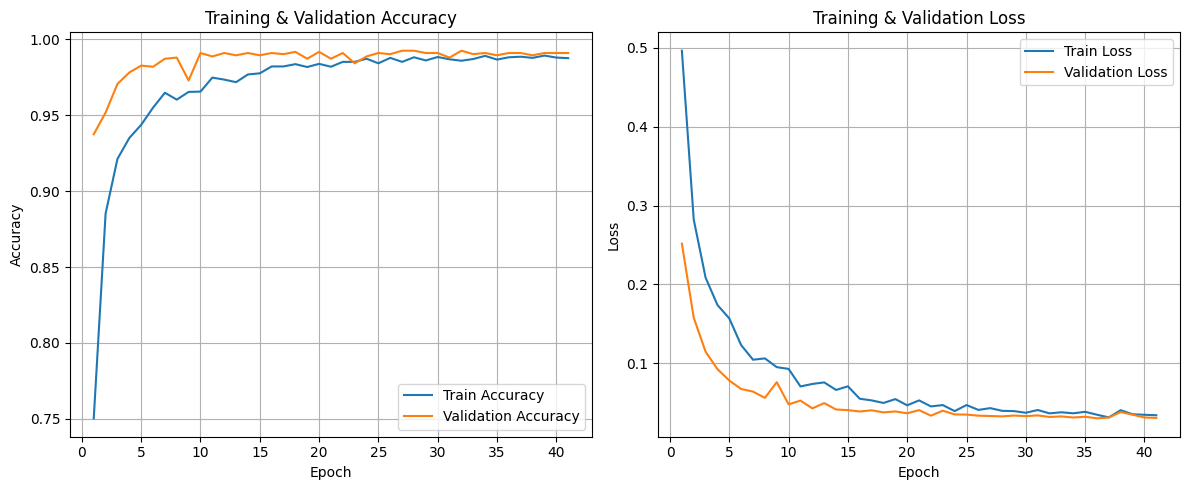

In [10]:
# Vẽ Accuracy và Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
